## Ngapi Semantic Chunker Tutorial
## Ye Kyaw Thu, Lab Leader, Language Understanding Lab, Myanmar
## Date: 26 July 2026

Github link: [https://github.com/ye-kyaw-thu/NgaPi](https://github.com/ye-kyaw-thu/NgaPi)  
Reference Youtube Video: [https://www.youtube.com/watch?v=8OJC21T2SL4&t=2112s](https://www.youtube.com/watch?v=8OJC21T2SL4&t=2112s)  

## How Semantic Tokenization (Chunking) Works in ngapi.py

The provided script (ngapi.py) implements a semantic text chunking algorithm based on embedding distances. Instead of splitting text strictly by fixed character lengths or punctuation, it looks at how the meaning of text shifts continuously using FastText word embeddings and cosine distance.  

Here is the step-by-step breakdown of how the process works:  

1. Syllable Breaking & Grouping:  
   - If `--apply_syllable_break` is enabled, regular expressions break the raw Myanmar text down into individual syllables.  
   - It then groups these pieces into uniform blocks based on `--syllable_group_length` (e.g., groups of 6 syllables) to form base units (sentences/tokens).
2. Context Window Expansion (Combining Sentences):
   - Using the `combine_sentences` function, each text group is merged with its surrounding neighbors (using a buffer size) to create a combined_sentence. This ensures that local context is preserved when calculating meaning.
3. Document Embedding Generation:  
   - The script loads a FastText binary model (`.bin`) and maps each word to its vector. 
   - It calculates the mean embedding vector for each combined sentence group (`embed_documents`).  
4. Distance Calculation:  
   - It computes the cosine similarity between sequential combined sentence vectors, and transforms it into a distance metric: $\text{Distance} = 1 - \text{Cosine Similarity}$. A higher distance indicates a sharper shift in topic or meaning.  
5. Thresholding & Splitting (The Semantic Breakpoints):  
   - A cutoff threshold is calculated using a percentile threshold (e.g., `--percentile_threshold 70`, meaning distances in the top 30% are treated as significant topic shifts).
   - Points where the distance exceeds this threshold are marked as breakpoints (boundaries where a new semantic chunk begins).  
6. Reconstruction & Formatting:  
   - The text segments between breakpoints are merged back together (stripping internal spaces and joining syllables with `--syllable_group_separator`) to form final semantic chunks.



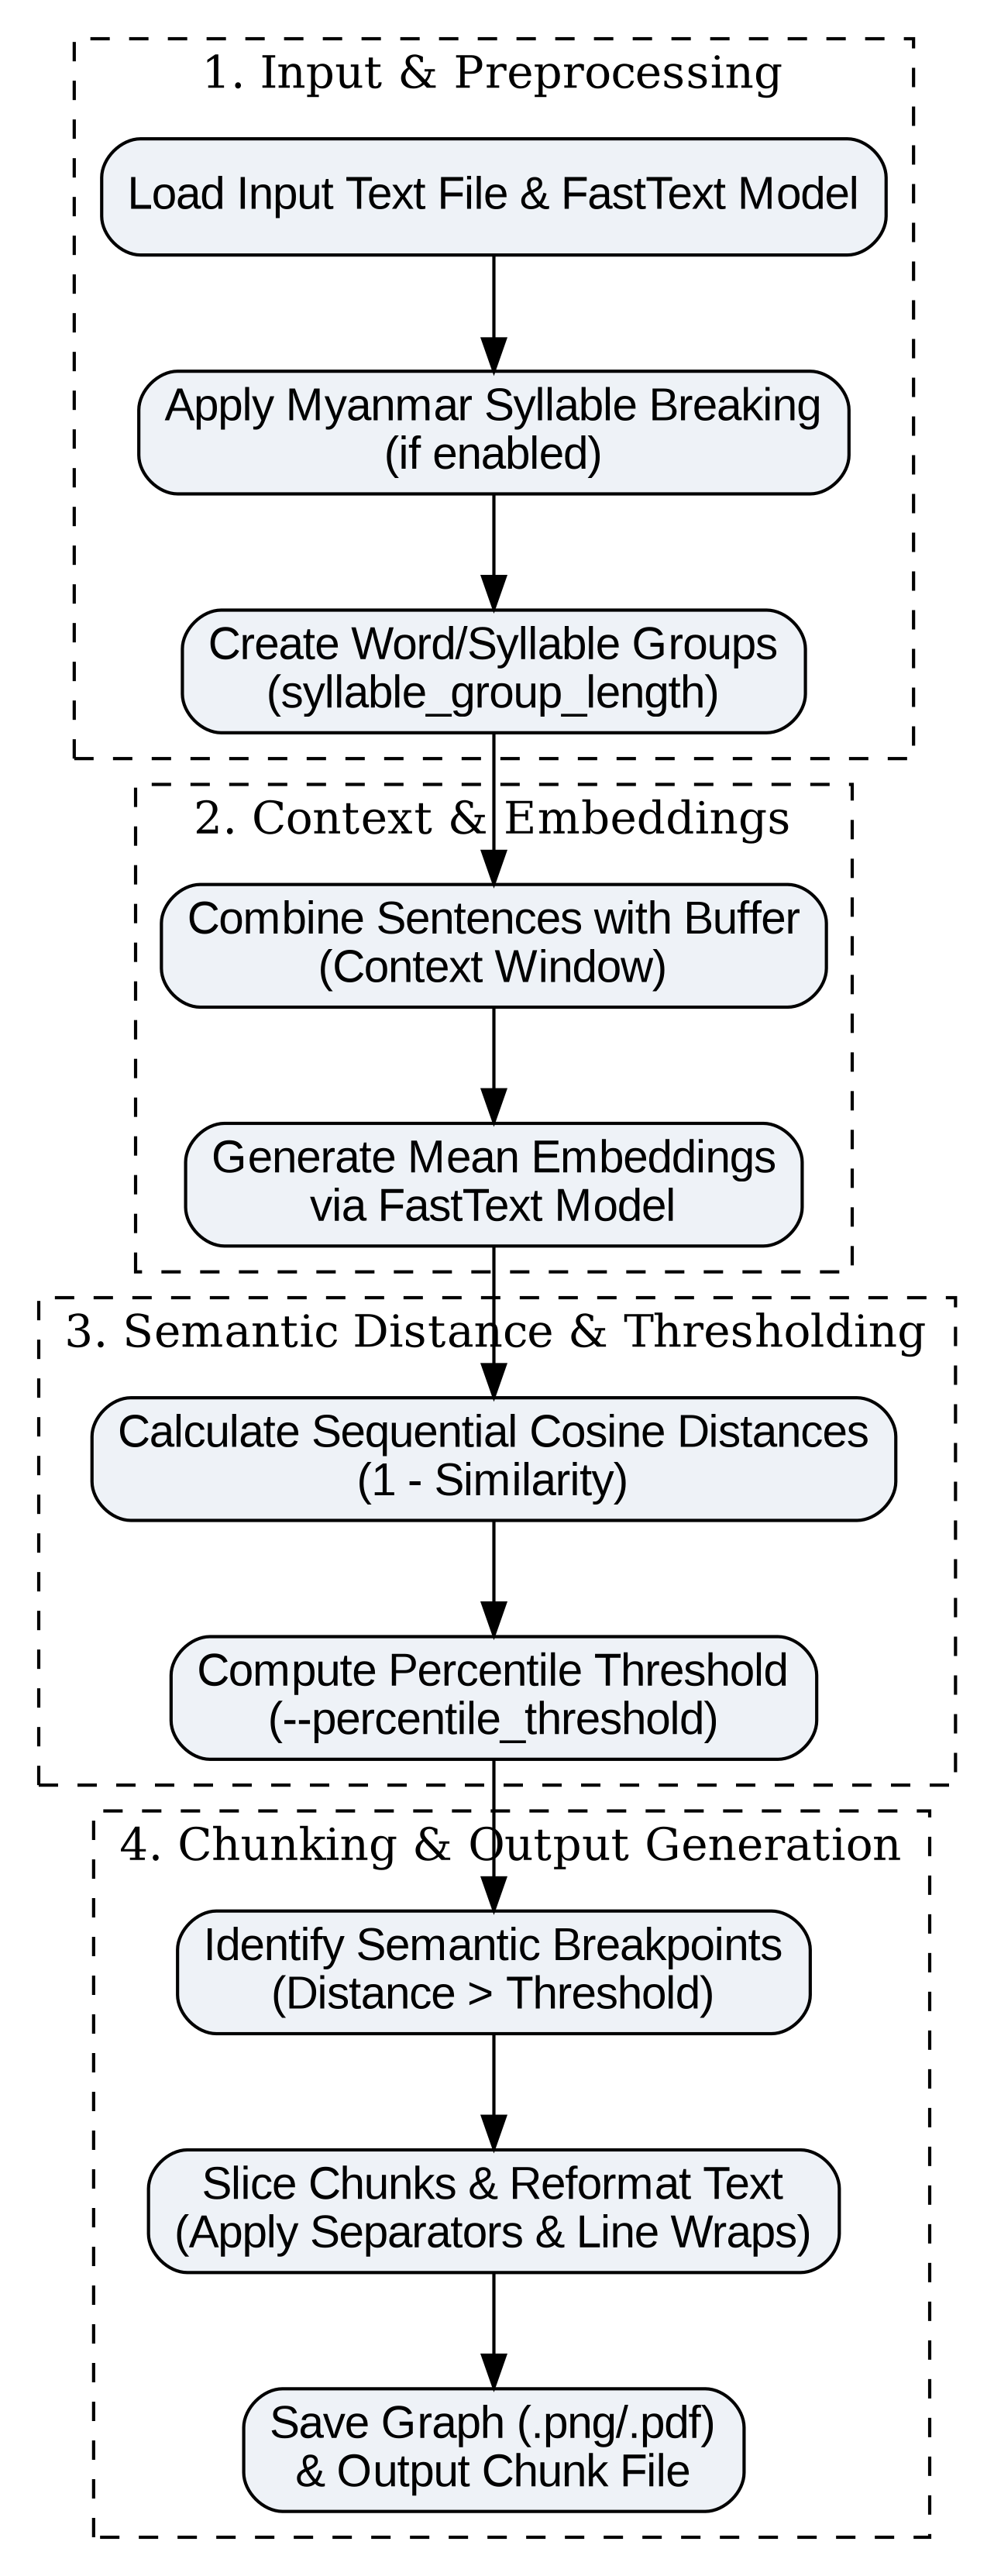

In [50]:
from IPython.display import Image, display

display(Image(filename='overview.png', width=300)) 

In [1]:
%pwd

'/home/ye/aif2/word-seg'

In [2]:
%cd tool

/home/ye/aif2/word-seg/tool


In [3]:
!mkdir ngapi

In [4]:
%cd ngapi

/home/ye/aif2/word-seg/tool/ngapi


In [5]:
!wget https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/ngapi.py

--2026-07-26 10:40:47--  https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/ngapi.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/ngapi.py [following]
--2026-07-26 10:40:47--  https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/ngapi.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10749 (10K) [text/plain]
Saving to: ‘ngapi.py’

ngapi.py            100%[===================>]  10.50K  --.-KB/s    in 0s      

2026-07-26 10:40:48 (37.0 MB/s) - ‘ngapi.py’ saved [10749/10749]



## Prepare Data

In [6]:
!wget https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/ma_thaung.txt

--2026-07-26 10:41:42--  https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/ma_thaung.txt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/ma_thaung.txt [following]
--2026-07-26 10:41:42--  https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/ma_thaung.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1670 (1.6K) [text/plain]
Saving to: ‘ma_thaung.txt’

ma_thaung.txt       100%[===================>]   1.63K  --.-KB/s    in 0s      

2026-07-26 10:41:43 (21.8 MB/s) - ‘ma_thaung.txt’ saved [1670/1670]



In [7]:
!wget https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/ma_thein.txt

--2026-07-26 10:42:03--  https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/ma_thein.txt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/ma_thein.txt [following]
--2026-07-26 10:42:03--  https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/ma_thein.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2836 (2.8K) [text/plain]
Saving to: ‘ma_thein.txt’

ma_thein.txt        100%[===================>]   2.77K  --.-KB/s    in 0s      

2026-07-26 10:42:04 (33.6 MB/s) - ‘ma_thein.txt’ saved [2836/2836]



## Prepare Shell Scripts

In [28]:
!wget https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/exp1.sh

--2026-07-26 14:00:36--  https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/exp1.sh
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/exp1.sh [following]
--2026-07-26 14:00:36--  https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/exp1.sh
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1729 (1.7K) [text/plain]
Saving to: ‘exp1.sh.1’

exp1.sh.1           100%[===================>]   1.69K  --.-KB/s    in 0s      

2026-07-26 14:00:37 (25.2 MB/s) - ‘exp1.sh.1’ saved [1729/1729]



In [29]:
from IPython.display import Markdown

# Read the shell script file
with open("exp1.sh", "r") as file:
    script_content = file.read()

# Print with syntax highlighting using Markdown
display(Markdown(f"```bash\n{script_content}\n```"))

```bash
#!/bin/bash

## Test commands run by Ye, LU Lab., Myanmar
## Test input filename is ma_thein.txt.
## Date: 25 Dec 2024

mkdir exp1;

## Test-1
time python ./ngapi.py --model ./myanmar_fasttext.model --input ./ma_thein.txt \
--graph_filename ./exp1/tst1.distances-eg1 --chunk_filename ./exp1/ma_thein.chunk1.txt  --apply_syllable_break \
--syllable_group_separator "_" --chunk_separator "|"

## Test-2
time python ./ngapi.py --model ./myanmar_fasttext.model --input ./ma_thein.txt \
--graph_filename ./exp1/tst1.distances-eg2 --chunk_filename ./exp1/ma_thein.chunk2.txt --percentile_threshold 40 \
--apply_syllable_break --chunks_per_line 5 \
--syllable_group_separator "_" --chunk_separator "|"

## Test-3
time python ./ngapi.py --model ./myanmar_fasttext.model --input ./ma_thein.txt \
--graph_filename ./exp1/tst1.distances-eg3 --chunk_filename ./exp1/ma_thein.chunk3.txt --percentile_threshold 30 \
--y_upper_bound 0.5 --apply_syllable_break --chunks_per_line 5 \
--syllable_group_separator "_" --chunk_separator "|"

## Test-4
time python ./ngapi.py --model ./myanmar_fasttext.model --input ./ma_thein.txt \
--graph_filename ./exp1/tst1.distances-eg4 --chunk_filename ./exp1/ma_thein.chunk4.txt --percentile_threshold 70 \
--y_upper_bound 0.5 --syllable_group_length 5 --apply_syllable_break \
--chunks_per_line 10 --syllable_group_separator "_" --chunk_separator "|"

## Test-5
time python ./ngapi.py --model ./myanmar_fasttext.model --input ./ma_thein.txt \
--graph_filename ./exp1/tst1.distances-eg5 --chunk_filename ./exp1/ma_thein.chunk5.txt --percentile_threshold 70 \
--y_upper_bound 0.1 --syllable_group_length 1 --apply_syllable_break \
--chunks_per_line 10 --syllable_group_separator "_" --chunk_separator "|"

```

In [31]:
!wget https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/exp2.sh

--2026-07-26 14:01:07--  https://github.com/ye-kyaw-thu/NgaPi/raw/refs/heads/main/test/exp2.sh
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/exp2.sh [following]
--2026-07-26 14:01:07--  https://raw.githubusercontent.com/ye-kyaw-thu/NgaPi/refs/heads/main/test/exp2.sh
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1740 (1.7K) [text/plain]
Saving to: ‘exp2.sh.1’

exp2.sh.1           100%[===================>]   1.70K  --.-KB/s    in 0s      

2026-07-26 14:01:08 (24.6 MB/s) - ‘exp2.sh.1’ saved [1740/1740]



In [32]:
from IPython.display import Markdown

# Read the shell script file
with open("exp2.sh", "r") as file:
    script_content = file.read()

# Print with syntax highlighting using Markdown
display(Markdown(f"```bash\n{script_content}\n```"))

```bash
#!/bin/bash

## Test commands run by Ye, LU Lab., Myanmar
## Test input filename is ma_thaung.txt.
## Date: 25 Dec 2024

mkdir exp2;
## Test-1
time python ./ngapi.py --model ./model/myfasttext_v1.bin --input ./ma_thaung.txt \
--graph_filename ./exp2/tst2.distances-eg1 --chunk_filename ./exp2/ma_thaung.chunk1.txt \
--apply_syllable_break --chunks_per_line 3 \
--syllable_group_separator "_" --chunk_separator "|"

## Test-2
time python ./ngapi.py --model ./model/myfasttext_v1.bin --input ./ma_thaung.txt \
--graph_filename ./exp2/tst2.distances-eg2 --chunk_filename ./exp2/ma_thaung.chunk2.txt \
--percentile_threshold 50 --apply_syllable_break \
--syllable_group_separator "_" --chunk_separator "|"

## Test-3
time python ./ngapi.py --model ./model/myfasttext_v1.bin --input ./ma_thaung.txt \
--graph_filename ./exp2/tst2.distances-eg3 --chunk_filename ./exp2/ma_thaung.chunk3.txt \
--percentile_threshold 60 --y_upper_bound 0.6 --apply_syllable_break --chunks_per_line 2 \
--syllable_group_separator "_" --chunk_separator "|"

## Test-4
time python ./ngapi.py --model ./model/myfasttext_v1.bin --input ./ma_thaung.txt \
--graph_filename ./exp2/tst2.distances-eg4 --chunk_filename ./exp2/ma_thaung.chunk4.txt \
--percentile_threshold 70 --y_upper_bound 0.6 --syllable_group_length 5 --apply_syllable_break \
--chunks_per_line 10 --syllable_group_separator "_" --chunk_separator "|"

## Test-5
time python ./ngapi.py --model ./model/myfasttext_v1.bin --input ./ma_thaung.txt \
--graph_filename ./exp2/tst2.distances-eg5 --chunk_filename ./exp2/ma_thaung.chunk5.txt \
--percentile_threshold 30 --y_upper_bound 0.5 --syllable_group_length 1 --apply_syllable_break \
--chunks_per_line 10 --syllable_group_separator "_" --chunk_separator "|"

```

## Prepare FastText Model File

In [26]:
!wget https://huggingface.co/ye-nlp/mySyllableFastText-Version1/resolve/main/myfasttext_v1.bin

--2026-07-26 10:54:17--  https://huggingface.co/ye-nlp/mySyllableFastText-Version1/resolve/main/myfasttext_v1.bin
Resolving huggingface.co (huggingface.co)... 18.65.14.87, 18.65.14.85, 18.65.14.125, ...
Connecting to huggingface.co (huggingface.co)|18.65.14.87|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/676c1caa8e7401029b2d2fcf/09ee10ac89348ba42bd9b4207e9566920d2cd0d63372f8c2912c0975c746f555?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27myfasttext_v1.bin%3B+filename%3D%22myfasttext_v1.bin%22%3B&response-content-type=application%2Foctet-stream&X-Xet-Cas-Uid=public&Expires=1785041658&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjc2YzFjYWE4ZTc0MDEwMjliMmQyZmNmLzA5ZWUxMGFjODkzNDhiYTQyYmQ5YjQyMDdlOTU2NjkyMGQyY2QwZDYzMzcyZjhjMjkxMmMwOTc1Yzc0NmY1NTVcXD91c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQSU

In [27]:
!ls *

exp1.sh  exp2.sh  ma_thaung.txt  ma_thein.txt  myfasttext_v1.bin  ngapi.py

exp1:


In [33]:
!mv myfasttext_v1.bin ./model/

## FastText Python Library Installation

In [24]:
!pip install fasttext --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4553716 sha256=06b35d16c49f4ec68f2d3bb465352abe1b37fc2baf9fa3f9c1c8bc60b0ae04ba
  Stored in directory: /mnt/disk1/ye/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fasttext]


## Run Experiment-1

In [34]:
%pwd

'/home/ye/aif2/word-seg/tool/ngapi'

In [15]:
!time ./exp1.sh

/bin/bash: line 1: ./exp1.sh: Permission denied

real	0m0.002s
user	0m0.001s
sys	0m0.000s


In [16]:
!ls *.sh -lh

-rw-rw-r-- 1 ye ye 1.7K Jul 26 10:42 exp1.sh
-rw-rw-r-- 1 ye ye 1.7K Jul 26 10:43 exp2.sh


In [17]:
!chmod +x *.sh

In [18]:
!ls *.sh -lh

-rwxrwxr-x 1 ye ye 1.7K Jul 26 10:42 exp1.sh
-rwxrwxr-x 1 ye ye 1.7K Jul 26 10:43 exp2.sh


In [36]:
!time ./exp1.sh

mkdir: cannot create directory ‘exp1’: File exists
No. of chunks:  16
Chunk line #1
ရွှေတိဂုံဘုရားအ
Chunk line #2
နောက်ဘက်စောင်းတန်းမှာမ_သိန်းဆိုတဲ့ပန်းသည်တ_ယောက်ရှိတယ်။ပန်းသည်
Chunk line #3
မသိန်းပုံကိုသိပ္ပံမောင်_ဝရေးဖွဲခဲ့ပုံက
Chunk line #4
…။
Chunk line #5
“မသိန်းသည်ပန်းသည်
Chunk line #6
တို့အနက်အတော်ပင်_ယဉ်စစရှိ၏။_အပြောလည်းကောင်း၊သ_ဘောလည်းကောင်း၊အပြု_အပြင်ကလည်းကောင်း၊_သူ့မှာအကောင်းချည်းစု_နေလေတော့သည်။သို့_ဖြစ်သောကြောင့်တက္ကသိုလ်
Chunk line #7
ကျောင်းသားတွေသူ့ဆိုင်မှာ_ချည်းပန်းဝယ်ကြလေသည်_။”_အဲ့ဒီခေတ်ကတက္ကသိုလ်
Chunk line #8
ကျောင်းသားတွေဟာစနေ_၊တနင်္ဂနွေနေ့တွေ
Chunk line #9
မှာအုပ်စုလိုက်ဘုရား_တက်ပြီးမသိန်းဆိုင်က_ပန်းတွေဝယ်၊မသိန်း
Chunk line #10
ဆိုင်ရှေ့ကခုံမှာထိုင်_ပြီးစကားတွေဖောင်ဖွဲ့_ကြပါသတဲ့။_တချို့ရက်တွေဆိုရှေ့_ကအဖွဲ့ဖောင်ဖွဲ့နေ_တုန်းနောက်တဖွဲ့ရောက်လာ_လို့မထချင်ထချင်_နဲ့နေရာဖယ်ပေးရ_ဆိုပဲ။ဒီထဲမောင်_သိန်းခိုင်ဆိုတဲ့ကျောင်းသား
Chunk line #11
ကတော့တကိုယ်တော်။_သူကမသိန်းဆိုင်သိမ်း_ချိန်အထိနေပြီးဆိုင်_သိမ်းပြီးရင်အတူပြန်_တဲ့ထိမသိန်းနဲ့ရင်း_နှီးတယ်။ဒီလိုနဲ့
Chunk line #12
ကျောင်းသားဟေ

## Check exp1 Folder

In [45]:
!tree ./exp1

./exp1
├── ma_thein.chunk1.txt
├── ma_thein.chunk2.txt
├── ma_thein.chunk3.txt
├── ma_thein.chunk4.txt
├── ma_thein.chunk5.txt
├── tst1.distances-eg1.pdf
├── tst1.distances-eg1.png
├── tst1.distances-eg2.pdf
├── tst1.distances-eg2.png
├── tst1.distances-eg3.pdf
├── tst1.distances-eg3.png
├── tst1.distances-eg4.pdf
├── tst1.distances-eg4.png
├── tst1.distances-eg5.pdf
└── tst1.distances-eg5.png

1 directory, 15 files


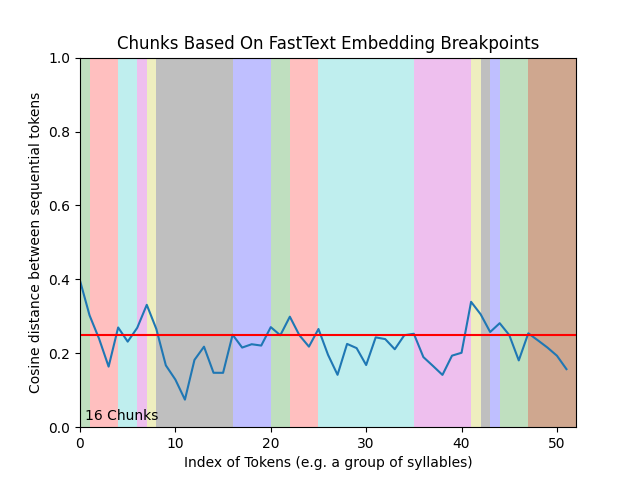

In [37]:
from IPython.display import Image

# Display the PNG image
Image(filename='./exp1/tst1.distances-eg1.png')

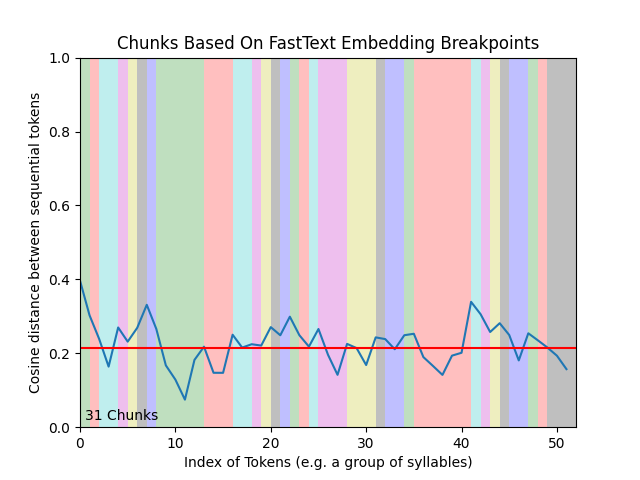

In [42]:
from IPython.display import Image

# Display the PNG image
Image(filename='./exp1/tst1.distances-eg2.png')

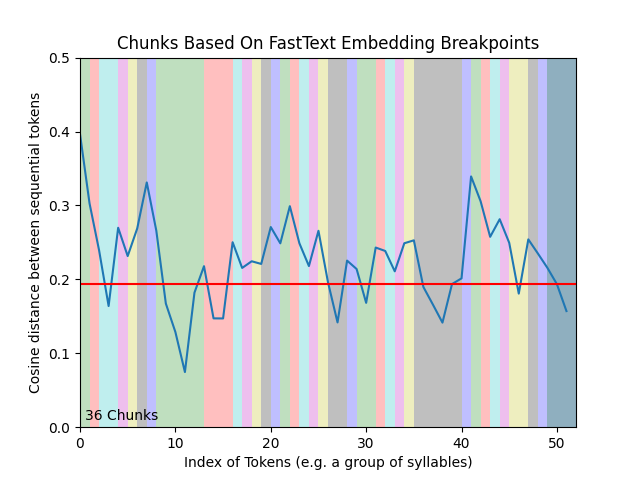

In [43]:
from IPython.display import Image

# Display the PNG image
Image(filename='./exp1/tst1.distances-eg3.png')

## Run Experiment-2

In [38]:
%pwd

'/home/ye/aif2/word-seg/tool/ngapi'

In [39]:
!./exp2.sh

No. of chunks:  9
Chunk line #1
ပန်းသည်မသောင်းကအ_သက်က၁၆နှစ်၊_ယဉ်စစနဲ့နုပျို|မှုခြင်းမှာမသိန်းထက်_အပုံကြီးသာသပေါ့_။ဒီတော့တက္ကသိုလ်ကျောင်း_သားတွေကပန်းသည်မ_သောင်းဆိုင်မှာပြောင်းပြီးပန်း_ဝယ်ကြ၊စကားတွေ_ဖောင်ဖွဲ့ကြတာပေါ့။_မသိန်းပန်းဆိုင်အရင်_လိုမရောင်းရတော့ဘဲ_ခြောက်ကပ်လာတာပေါ့။_ဒီလိုနဲ့တနေ့သူ့_ပန်းဆိုင်နားကိုလင်မ_ယားနှစ်ယောက်ကလေးလေး|လက်ဆွဲပြီးရောက်လာ။_အမျိုးသားဖြစ်သူက_တပ်ထားတဲ့မျက်မှန်ချွတ်_လိုက်ပြီးကျနော့်မှတ်မိ
Chunk line #2
လားမေး။မောင်သိန်းခိုင်_ဖြစ်နေ။ပန်းသည်မ|သိန်းနဲ့ယောကျ်ားဖြစ်သူ_ကိုသိန်းခိုင်တို့စကား_တွေတရင်းတနှီးဖောင်|ဖွဲ့နေကြတာကြည့်
Chunk line #3
ပြီးဇနီးဖြစ်သူက|အံ့တွေသြ။_သိပ္ပံမောင်ဝကဒီမှာ|တင်ပန်းသည်စာမူကို_ရပ်ခဲ့တယ်။
Chunks saved to ./exp2/ma_thaung.chunk1.txt

real	0m1.493s
user	0m6.085s
sys	0m0.424s
No. of chunks:  15
Chunk line #1
ပန်းသည်မသောင်းကအ_သက်က၁၆နှစ်၊
Chunk line #2
ယဉ်စစနဲ့နုပျို
Chunk line #3
မှုခြင်းမှာမသိန်းထက်
Chunk line #4
အပုံကြီးသာသပေါ့
Chunk line #5
။ဒီတော့တက္ကသိုလ်ကျောင်း_သားတွေကပန်းသည်မ_သောင်းဆိုင်မှာပြောင်းပြီးပန်း_ဝယ်ကြ၊စကားတွေ_ဖောင်ဖွဲ့ကြတာပေါ့။_မသိန်းပန်

## Check exp2 Folder

In [46]:
!tree ./exp2

./exp2
├── ma_thaung.chunk1.txt
├── ma_thaung.chunk2.txt
├── ma_thaung.chunk3.txt
├── ma_thaung.chunk4.txt
├── ma_thaung.chunk5.txt
├── tst2.distances-eg1.pdf
├── tst2.distances-eg1.png
├── tst2.distances-eg2.pdf
├── tst2.distances-eg2.png
├── tst2.distances-eg3.pdf
├── tst2.distances-eg3.png
├── tst2.distances-eg4.pdf
├── tst2.distances-eg4.png
├── tst2.distances-eg5.pdf
└── tst2.distances-eg5.png

1 directory, 15 files


## Check Output Grpahs

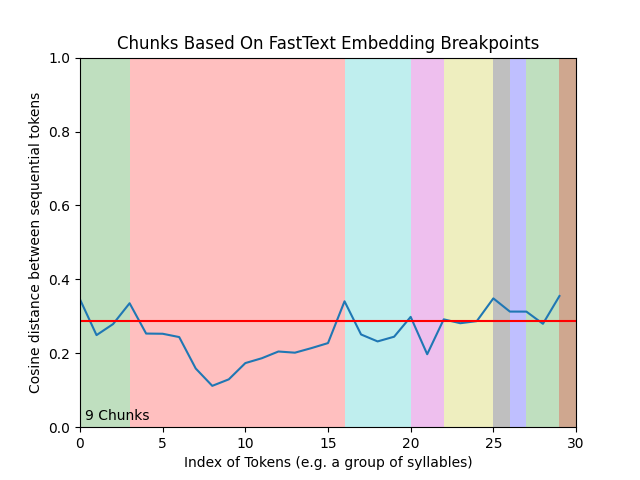

In [40]:
from IPython.display import Image

# Display the PNG image
Image(filename='./exp2/tst2.distances-eg1.png')

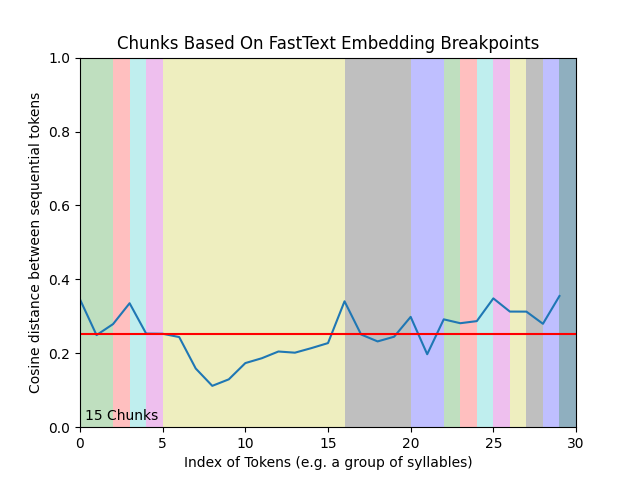

In [41]:
from IPython.display import Image

# Display the PNG image
Image(filename='./exp2/tst2.distances-eg2.png')

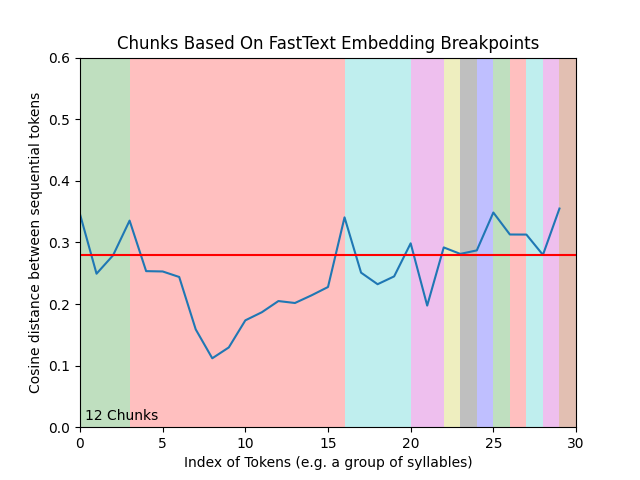

In [44]:
from IPython.display import Image

# Display the PNG image
Image(filename='./exp2/tst2.distances-eg3.png')